# ETHOS vs EveryQuery comparison

Per-code AUROC comparison of ETHOS (generative trajectory model, 20 sampled trajectories per (subject, prediction_time)) against the best EveryQuery checkpoint on the held-out MIMIC eval suite (`gs://every-query-runs/eval_tasks/7573f855…/held_out/`).

Pipeline: `build_mapping.py` → `predict.py` → `evaluate.py` → this notebook.

**Mapping tiers (stratified):**
- `exact` — EQ code is a literal ETHOS token.
- `drop_bin` — strip `value_[lo,hi)` and uppercase units, match ETHOS lab token; predicts presence of any value of that lab.
- `quantile` — match the lab token AND require the next-token Qk to fall in the decile corresponding to EQ's value bin.
- `union` — per-code OR over the prior tiers.

**Coverage caveat:** ETHOS's vocabulary uses descriptive ICD labels rather than codes, ATC for medications, and lacks `INFUSION_*` / `SUBJECT_FLUID_OUTPUT` / `TIMELINE_START` prefixes. Without crosswalks (out of scope for this pass) only LAB codes and `MEDS_DEATH` map cleanly. The unmapped follow-up table at the bottom enumerates what's missing and why.

**EQ checkpoint caveat:** the chosen best EQ checkpoint (`23-43-54`) has 40 codes; `MEDS_DEATH` is only evaluated by partial ckpts (`14-08-24`, `23-54-43`, both at duration 30 only). For the exact-tier comparison we fall back to those partial ckpts for `MEDS_DEATH`, with the source annotated in the per-code table.

In [1]:
import os, io, json
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from google.cloud import storage

# Set GOOGLE_APPLICATION_CREDENTIALS to your application_default_credentials.json before running.
BUCKET = 'every-query-runs'
CACHE = Path(os.environ.get('ETHOS_MAPPING_CACHE', '/tmp/eq_ethos_cache'))
CACHE.mkdir(parents=True, exist_ok=True)

client = storage.Client(project='every-query')
bucket = client.bucket(BUCKET)

def gload(blob_name, name=None):
    name = name or Path(blob_name).name
    p = CACHE / name
    if not p.exists():
        bucket.blob(blob_name).download_to_filename(str(p))
    return p

eq_aucs = pl.read_parquet(gload('eval_aucs_held_out.parquet'))
ethos_aucs = pl.read_parquet(gload('baselines/ethos/ethos_aucs_held_out.parquet'))
coverage = pl.read_parquet(gload('baselines/ethos/mapping_coverage.parquet'))
mapping = pl.read_parquet(gload('baselines/ethos/mapping_table.parquet'))
with open(Path('best_eq_ckpt.json')) as f:
    best_eq = json.load(f)
best_model = best_eq['model']
print('Best EQ checkpoint:', best_model, '(mean AUC %.4f)' % best_eq['mean_occurs_auc'])
print('ETHOS sims/subject:', 20)
print('Comparison durations:', sorted(set(ethos_aucs['duration_days'].to_list())))
print('Mapping tiers:', sorted(set(mapping['tier'].to_list())))
print('ETHOS-mapped codes:', mapping['query'].n_unique())

Best EQ checkpoint: 23-43-54 (mean AUC 0.8518)
ETHOS sims/subject: 20
Comparison durations: [30, 180]
Mapping tiers: ['atc_crosswalk', 'drop_bin', 'exact', 'icd_crosswalk', 'mimic_item_crosswalk', 'quantile', 'union']
ETHOS-mapped codes: 28


/tmp/eqvenv/lib/python3.11/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


## 1. Coverage by tier × family

How many EQ codes from each family did each tier successfully map?

In [2]:
fam = lambda c: c.split('//', 1)[0]
by_family = (
    coverage.group_by('family')
    .agg(
        pl.len().alias('n_codes'),
        pl.col('is_unmapped').sum().alias('n_unmapped'),
    )
    .with_columns((pl.col('n_codes') - pl.col('n_unmapped')).alias('n_mapped'))
    .select('family', 'n_codes', 'n_mapped', 'n_unmapped')
    .sort('family')
)
by_family.to_pandas()

,family,n_codes,n_mapped,n_unmapped
0,DIAGNOSIS,5,5,0
1,INFUSION_END,3,3,0
2,INFUSION_START,3,3,0
3,LAB,19,9,10
4,MEDICATION,5,5,0
5,MEDS_DEATH,1,1,0
6,PROCEDURE,1,1,0
7,SUBJECT_FLUID_OUTPUT,3,0,3
8,TIMELINE,1,1,0


In [3]:
tier_codes = (
    mapping.select('query', 'tier').unique()
    .with_columns(pl.col('query').map_elements(fam, return_dtype=pl.String).alias('family'))
)
tier_x_family = (
    tier_codes.group_by(['tier', 'family']).agg(pl.col('query').n_unique().alias('n_codes'))
    .pivot(index='family', on='tier', values='n_codes')
    .sort('family')
    .fill_null(0)
)
tier_x_family.to_pandas()

,family,drop_bin,exact,union,mimic_item_crosswalk,quantile,atc_crosswalk,icd_crosswalk
0,DIAGNOSIS,0,0,5,0,0,0,5
1,INFUSION_END,0,0,3,3,0,0,0
2,INFUSION_START,0,0,3,3,0,0,0
3,LAB,6,0,9,3,3,0,0
4,MEDICATION,0,0,5,0,0,5,0
5,MEDS_DEATH,0,1,1,0,0,0,0
6,PROCEDURE,0,0,1,0,0,0,1
7,TIMELINE,0,0,1,1,0,0,0


## 2. Per-code AUROC: EQ vs ETHOS

EQ AUC primarily comes from the best checkpoint (`23-43-54`). For codes the best checkpoint did not evaluate (`MEDS_DEATH`), we fall back to the next-best EQ checkpoint that did evaluate them — `eq_source` records which. Scatter facets are by `(duration_days, bucket)` per tier.

In [4]:
# EQ AUCs: prefer best checkpoint; fall back to whichever ckpt did evaluate the code (max AUC chosen for tie-breaking).
eq_best = (
    eq_aucs.filter(pl.col('model') == best_model)
    .select(
        pl.col('code').alias('query'),
        pl.col('duration_days').cast(pl.Int64),
        'bucket',
        pl.col('occurs_auc').alias('eq_auc'),
        pl.lit(best_model).alias('eq_source'),
    )
)
ethos_keys = ethos_aucs.select(
    pl.col('code').alias('query'),
    pl.col('duration_days').cast(pl.Int64),
    'bucket',
).unique()
needs_fallback = ethos_keys.join(eq_best, on=['query', 'duration_days', 'bucket'], how='anti')
fallback = (
    eq_aucs.filter(pl.col('model') != best_model)
    .select(
        pl.col('code').alias('query'),
        pl.col('duration_days').cast(pl.Int64),
        'bucket',
        pl.col('occurs_auc').alias('eq_auc'),
        pl.col('model').alias('eq_source'),
    )
    .group_by(['query', 'duration_days', 'bucket'])
    .agg(
        pl.col('eq_auc').max().alias('eq_auc'),
        pl.col('eq_source').sort_by('eq_auc', descending=True).first().alias('eq_source'),
    )
    .join(needs_fallback, on=['query', 'duration_days', 'bucket'], how='inner')
)
eq_full = pl.concat([eq_best, fallback], how='vertical_relaxed')
et = (
    ethos_aucs.select(
        pl.col('code').alias('query'),
        pl.col('duration_days').cast(pl.Int64),
        'bucket', 'tier',
        pl.col('occurs_auc').alias('ethos_auc'),
        'n_rows', 'n_positive',
    )
)
merged = et.join(eq_full, on=['query', 'duration_days', 'bucket'], how='inner')
print('Joined rows:', len(merged), '| with best ckpt:', merged.filter(pl.col("eq_source") == best_model).height, '| fallback:', merged.filter(pl.col("eq_source") != best_model).height)
merged.to_pandas().head(30)

Joined rows: 116 | with best ckpt: 114 | fallback: 2


,query,duration_days,bucket,tier,ethos_auc,n_rows,n_positive,eq_auc,eq_source
0,MEDICATION//Carbidopa-Levodopa (25-100)//Admin...,30,id,atc_crosswalk,0.945980,15031,64,0.669771,23-43-54
1,MEDICATION//START//Mupirocin Nasal Ointment 2%,30,id,atc_crosswalk,0.672944,15031,42,0.885333,23-43-54
2,MEDICATION//STOP//Doxycycline Hyclate,30,id,atc_crosswalk,0.745976,15031,157,0.704625,23-43-54
3,MEDICATION//Carbidopa-Levodopa (25-100)//Admin...,180,id,atc_crosswalk,0.970528,10550,49,0.675475,23-43-54
4,MEDICATION//START//Mupirocin Nasal Ointment 2%,180,id,atc_crosswalk,0.594416,10550,20,0.852053,23-43-54
5,MEDICATION//STOP//Doxycycline Hyclate,180,id,atc_crosswalk,0.744888,10550,130,0.710638,23-43-54
6,MEDICATION//Gabapentin//Delayed Administered,30,ood,atc_crosswalk,0.913016,15031,52,0.768579,23-43-54
7,MEDICATION//STOP//Captopril,30,ood,atc_crosswalk,0.718359,15031,151,0.824590,23-43-54
8,MEDICATION//Gabapentin//Delayed Administered,180,ood,atc_crosswalk,0.912893,10550,48,0.759700,23-43-54
9,MEDICATION//STOP//Captopril,180,ood,atc_crosswalk,0.703479,10550,107,0.820713,23-43-54


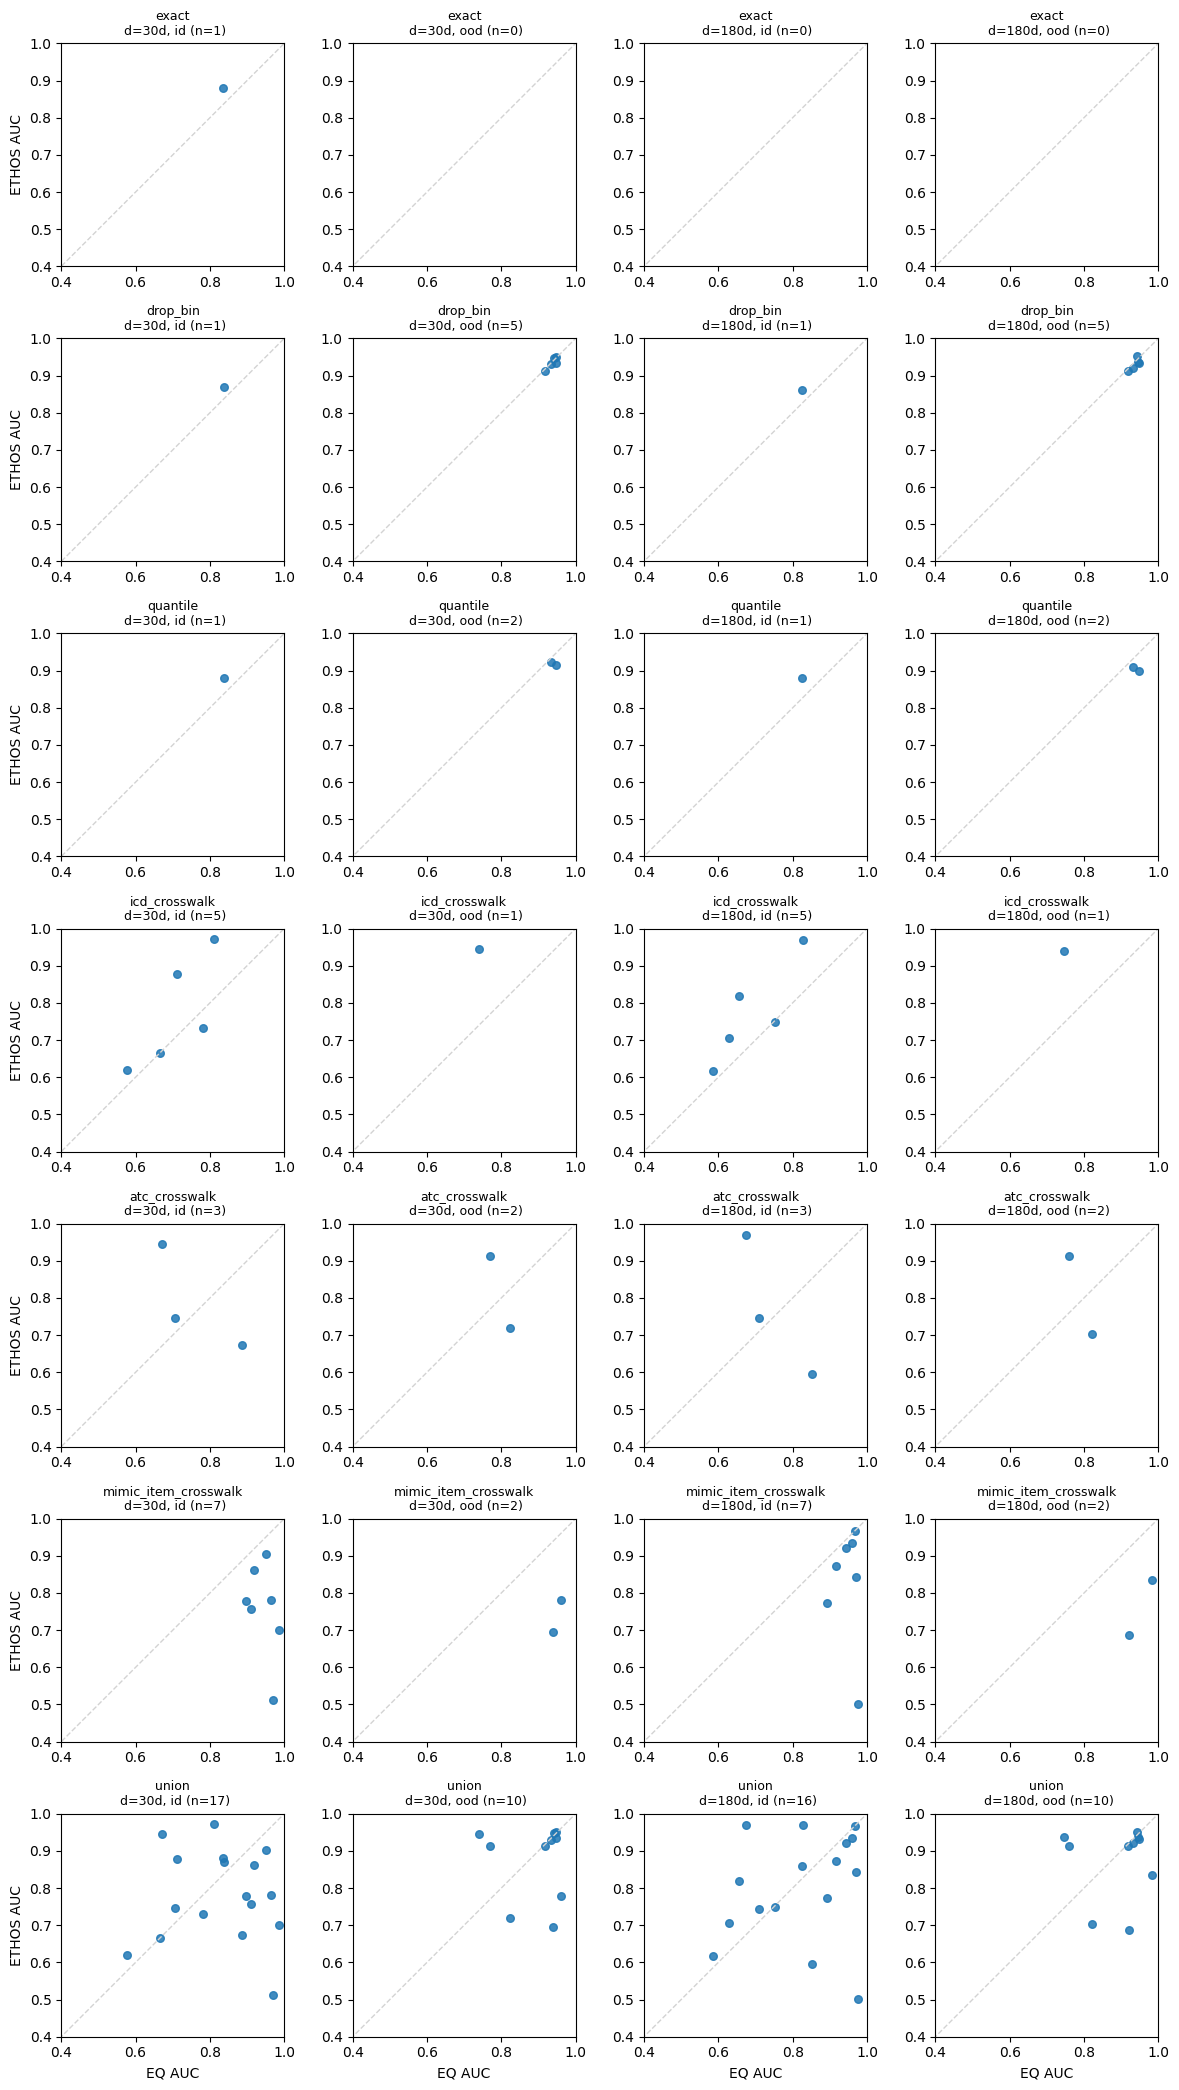

In [5]:
# Tier display order: primary tiers first (exact, drop_bin, quantile, crosswalks), then union as the per-code OR.
primary_tier_order = ['exact', 'drop_bin', 'quantile', 'icd_crosswalk', 'atc_crosswalk', 'mimic_item_crosswalk']
available_tiers = sorted(merged['tier'].unique().to_list())
tiers = [t for t in primary_tier_order if t in available_tiers] + (['union'] if 'union' in available_tiers else [])
durations = sorted(merged['duration_days'].unique().to_list())
buckets = ['id', 'ood']
fig, axes = plt.subplots(len(tiers), len(durations) * len(buckets), figsize=(3.0 * len(durations) * len(buckets), 3.0 * len(tiers)), squeeze=False)
for r, tier in enumerate(tiers):
    for cdi, d in enumerate(durations):
        for bi, b in enumerate(buckets):
            c = cdi * len(buckets) + bi
            ax = axes[r, c]
            sub = merged.filter((pl.col('tier') == tier) & (pl.col('duration_days') == d) & (pl.col('bucket') == b)).to_pandas()
            sub = sub.dropna(subset=['eq_auc', 'ethos_auc'])
            ax.plot([0, 1], [0, 1], color='lightgray', lw=1, ls='--')
            ax.scatter(sub['eq_auc'], sub['ethos_auc'], s=30, alpha=0.85)
            ax.set_xlim(0.4, 1.0); ax.set_ylim(0.4, 1.0)
            ax.set_aspect('equal')
            ax.set_title(f'{tier}\n d={d}d, {b} (n={len(sub)})', fontsize=9)
            if c == 0: ax.set_ylabel('ETHOS AUC')
            if r == len(tiers) - 1: ax.set_xlabel('EQ AUC')
plt.tight_layout()
plt.show()

## 3. Paired comparison: Wilcoxon signed-rank, EQ vs ETHOS

Pairs are matched on `(query, duration_days, bucket)`. A positive `mean_diff = ETHOS − EQ` means ETHOS wins on average; the p-value tests the null that the median difference is zero. Sample sizes are small (max n=12 at the union tier) — the test is exploratory.

In [6]:
rows = []
for tier in tiers:
    for d in durations:
        for b in buckets:
            sub = merged.filter((pl.col('tier') == tier) & (pl.col('duration_days') == d) & (pl.col('bucket') == b)).to_pandas()
            sub = sub.dropna(subset=['eq_auc', 'ethos_auc'])
            n = len(sub)
            row = {'tier': tier, 'duration_days': d, 'bucket': b, 'n': n}
            if n >= 1:
                row['mean_eq'] = float(sub['eq_auc'].mean())
                row['mean_ethos'] = float(sub['ethos_auc'].mean())
                row['mean_diff'] = float((sub['ethos_auc'] - sub['eq_auc']).mean())
            else:
                row.update({'mean_eq': np.nan, 'mean_ethos': np.nan, 'mean_diff': np.nan})
            if n >= 2:
                try:
                    row['p_value'] = float(wilcoxon(sub['ethos_auc'], sub['eq_auc']).pvalue)
                except ValueError:
                    row['p_value'] = np.nan
            else:
                row['p_value'] = np.nan
            rows.append(row)
stats_df = pd.DataFrame(rows).sort_values(['tier', 'duration_days', 'bucket']).reset_index(drop=True)
stats_df

,tier,duration_days,bucket,n,mean_eq,mean_ethos,mean_diff,p_value
0,atc_crosswalk,30,id,3,0.753243,0.788300,0.035057,0.750000
1,atc_crosswalk,30,ood,2,0.796585,0.815688,0.019103,1.000000
2,atc_crosswalk,180,id,3,0.746055,0.769944,0.023889,0.750000
3,atc_crosswalk,180,ood,2,0.790207,0.808186,0.017979,1.000000
4,drop_bin,30,id,1,0.838833,0.869466,0.030634,NaN
5,drop_bin,30,ood,5,0.937815,0.934669,-0.003146,0.437500
6,drop_bin,180,id,1,0.825853,0.860095,0.034242,NaN
7,drop_bin,180,ood,5,0.936290,0.931264,-0.005026,0.437500
8,exact,30,id,1,0.834075,0.879992,0.045917,NaN
9,exact,30,ood,0,NaN,NaN,NaN,NaN


In [7]:
print('Aggregated across (duration, bucket) per tier:')
for tier in tiers:
    sub = merged.filter(pl.col('tier') == tier).to_pandas().dropna(subset=['eq_auc', 'ethos_auc'])
    n = len(sub)
    if n < 2:
        msg_p = 'NA'
        diff = sub['ethos_auc'].mean() - sub['eq_auc'].mean() if n else float('nan')
    else:
        try:
            p = wilcoxon(sub['ethos_auc'], sub['eq_auc']).pvalue
            msg_p = f'{p:.3g}'
        except ValueError:
            msg_p = 'NA'
        diff = (sub['ethos_auc'] - sub['eq_auc']).mean()
    print(f'  {tier:>10s}  n={n:3d}  mean_eq={sub["eq_auc"].mean():.3f}  mean_ethos={sub["ethos_auc"].mean():.3f}  mean_diff={diff:+.3f}  p={msg_p}')

Aggregated across (duration, bucket) per tier:
       exact  n=  1  mean_eq=0.834  mean_ethos=0.880  mean_diff=+0.046  p=NA
    drop_bin  n= 12  mean_eq=0.920  mean_ethos=0.922  mean_diff=+0.002  p=0.85
    quantile  n=  6  mean_eq=0.904  mean_ethos=0.901  mean_diff=-0.003  p=1
  icd_crosswalk  n= 12  mean_eq=0.707  mean_ethos=0.801  mean_diff=+0.094  p=0.0122
  atc_crosswalk  n= 10  mean_eq=0.767  mean_ethos=0.792  mean_diff=+0.025  p=0.625
  mimic_item_crosswalk  n= 18  mean_eq=0.946  mean_ethos=0.784  mean_diff=-0.162  p=1.53e-05
       union  n= 53  mean_eq=0.850  mean_ethos=0.822  mean_diff=-0.028  p=0.27


## 4. Per-code table (long form)

Every (query, duration_days, bucket, tier) cell that successfully mapped, with EQ AUC, ETHOS AUC, and the EQ source ckpt.

In [8]:
table = (
    merged.select('query', 'duration_days', 'bucket', 'tier', 'eq_auc', 'ethos_auc', 'eq_source', 'n_rows', 'n_positive')
    .with_columns((pl.col('ethos_auc') - pl.col('eq_auc')).alias('ethos_minus_eq'))
    .sort(['tier', 'duration_days', 'bucket', 'query'])
)
table.to_pandas()

,query,duration_days,bucket,tier,eq_auc,ethos_auc,eq_source,n_rows,n_positive,ethos_minus_eq
0,MEDICATION//Carbidopa-Levodopa (25-100)//Admin...,30,id,atc_crosswalk,0.669771,0.945980,23-43-54,15031,64,0.276209
1,MEDICATION//START//Mupirocin Nasal Ointment 2%,30,id,atc_crosswalk,0.885333,0.672944,23-43-54,15031,42,-0.212389
2,MEDICATION//STOP//Doxycycline Hyclate,30,id,atc_crosswalk,0.704625,0.745976,23-43-54,15031,157,0.041351
3,MEDICATION//Gabapentin//Delayed Administered,30,ood,atc_crosswalk,0.768579,0.913016,23-43-54,15031,52,0.144437
4,MEDICATION//STOP//Captopril,30,ood,atc_crosswalk,0.824590,0.718359,23-43-54,15031,151,-0.106231
...,...,...,...,...,...,...,...,...,...,...
111,"LAB//224690//insp/min//value_[14.0,16.0)",180,ood,union,0.931539,0.921606,23-43-54,10550,205,-0.009933
112,"LAB//227073//mEq/L//value_[17.0,19.0)",180,ood,union,0.917641,0.913330,23-43-54,10550,290,-0.004311
113,MEDICATION//Gabapentin//Delayed Administered,180,ood,union,0.759700,0.912893,23-43-54,10550,48,0.153192
114,MEDICATION//STOP//Captopril,180,ood,union,0.820713,0.703479,23-43-54,10550,107,-0.117234


## 5. Codes left unmapped — follow-up candidates

Sorted within family by EQ AUC (descending) so the highest-leverage targets come first: codes EQ predicts well that ETHOS currently can't be evaluated on are the ones we lose the most signal on. The `unmapped_reason` column is the natural starting point for adding the next mapping tier (e.g. ICD-9/10 ↔ ETHOS descriptive labels, drug-name ↔ ATC, etc.).

In [9]:
# Use the same fallback EQ AUC as in section 2 so unmapped DIAGNOSIS / MEDICATION codes (only in partial ckpts) still get an EQ AUC for prioritisation.
eq_for_unmapped = eq_full.rename({'query': 'code'}).select('code', 'duration_days', 'bucket', 'eq_auc')
unmapped = (
    coverage.filter(pl.col('is_unmapped'))
    .rename({'query': 'code'})
    .join(eq_for_unmapped, on='code', how='left')
    .select('family', 'code', 'duration_days', 'bucket', 'eq_auc', 'unmapped_reason')
    .unique()
    .sort(['family', 'eq_auc'], descending=[False, True])
)
print(f'{unmapped.height} unmapped (code, duration, bucket) cells')
unmapped.to_pandas()

26 unmapped (code, duration, bucket) cells


,family,code,duration_days,bucket,eq_auc,unmapped_reason
0,LAB,"LAB//51769//UNK//value_[1.88,2.29)",30,ood,NaN,value_bin_or_units_unmatched
1,LAB,"LAB//51769//UNK//value_[1.88,2.29)",180,ood,0.976378,value_bin_or_units_unmatched
2,LAB,"LAB//229663//cmH2O//value_[-inf,5.0)",30,ood,0.973106,value_bin_or_units_unmatched
3,LAB,"LAB//229663//cmH2O//value_[-inf,5.0)",180,ood,0.963253,value_bin_or_units_unmatched
4,LAB,"LAB//229694//UNK//value_[0.0,inf)",180,ood,0.946341,value_bin_or_units_unmatched
5,LAB,"LAB//229694//UNK//value_[0.0,inf)",30,ood,0.944403,value_bin_or_units_unmatched
6,LAB,"LAB//220245//ml/min//value_[173.0,188.0)",180,id,0.939719,value_bin_or_units_unmatched
7,LAB,"LAB//220245//ml/min//value_[173.0,188.0)",30,id,0.936587,value_bin_or_units_unmatched
8,LAB,"LAB//225672//IU/L//value_[30.0,42.0)",30,id,0.926805,value_bin_or_units_unmatched
9,LAB,"LAB//225640//%//value_[0.3,0.6)",30,id,0.893654,value_bin_or_units_unmatched


In [10]:
(
    coverage.filter(pl.col('is_unmapped'))
    .group_by('unmapped_reason')
    .agg(pl.len().alias('n_codes'))
    .sort('n_codes', descending=True)
    .to_pandas()
)

,unmapped_reason,n_codes
0,value_bin_or_units_unmatched,10
1,ethos_token_missing/no_fluid_output_prefix_in_...,3
